
# 🏥 Medical Insurance Cost Prediction

### 📌 About the Dataset

This dataset contains **1,338 records** of individuals with the following features:

* **age**: age of the primary beneficiary
* **sex**: insurance contractor gender (male/female)
* **bmi**: body mass index, providing an understanding of body weight relative to height
* **children**: number of children covered by health insurance
* **smoker**: whether the individual is a smoker (yes/no)
* **region**: residential area in the US (northeast, northwest, southeast, southwest)
* **charges**: individual medical costs billed by health insurance

Source: [Kaggle Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

---

### 📊 Project Workflow

1. **Exploratory Data Analysis (EDA):**

   * Distribution plots, count plots, and pair plots for relationships.
   * Categorical variables (`sex`, `smoker`, `region`) encoded using **One-Hot Encoding**.
   * Correlation analysis to identify most impactful features on `charges`.

2. **Model Training:**
   I experimented with multiple regression algorithms:

   * Linear Regression
   * Ridge Regression
   * Support Vector Regressor (SVR)
   * Decision Tree Regressor
   * Random Forest Regressor
   * XGBoost Regressor

3. **Evaluation Metrics:**

   * **RMSE (Root Mean Squared Error)** → measures prediction error in cost units
   * **MAE (Mean Absolute Error)** → average absolute error of predictions
   * **R² Score** → variance explained by the model

---

### ⚡ Results

| Model             | RMSE (Train) | RMSE (Test) | MAE (Train) | MAE (Test)  | R² (Train) | R² (Test) |
| ----------------- | ------------ | ----------- | ----------- | ----------- | ---------- | --------- |
| Linear Regression | 6059.47      | 5994.70     | 4184.16     | 4284.99     | 0.744      | 0.772     |
| Ridge Regression  | 6059.73      | 5999.23     | 4193.76     | 4298.06     | 0.744      | 0.772     |
| SVR               | 12529.05     | 13102.02    | 8210.76     | 8667.19     | -0.096     | -0.088    |
| Decision Tree     | 503.71       | 6669.90     | 30.72       | 2957.01     | 0.998      | 0.718     |
| Random Forest     | 1952.49      | **4772.96** | 1078.47     | **2654.28** | 0.973      | **0.856** |
| XGBoost           | 911.25       | 4953.87     | 466.95      | 2772.47     | 0.994      | 0.844     |

✅ **Best Performing Model:**

* **Random Forest Regressor** achieved the lowest test error with **RMSE ≈ 4773** and **R² ≈ 0.856**, making it the most reliable predictor of insurance charges.
* **XGBoost** also performed competitively.
* **Linear & Ridge** gave decent baseline performance.
* **SVR failed** to generalize for this dataset.

---

### 🛠️ Predictive System

After model evaluation, I built an **interactive prediction system** where a user can enter:

* Age
* Sex
* BMI
* Children
* Smoker status
* Region

And instantly receive a predicted insurance cost 💰.

---

### 🎯 Key Takeaways

* **Smoking** had the most significant impact on charges.
* **Random Forest** handled the dataset best, balancing bias & variance.
* Proper **feature encoding** and **model selection** are critical in regression tasks.
* The pipeline is extendable to real-world insurance companies for pricing strategies.

---

✨ This project blends **data analysis, model comparison, and deployment** into a practical ML pipeline for real-life cost predictions.



In [46]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [47]:
medic = pd.read_csv('archive.zip')

In [48]:
medic.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [49]:
medic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [50]:
medic['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


# Data Visualization

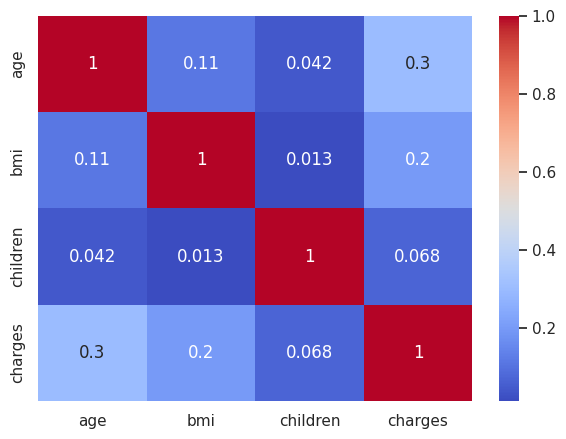

In [51]:
feature = medic.select_dtypes(include='number')

corr_matrix = feature.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

<Figure size 300x300 with 0 Axes>

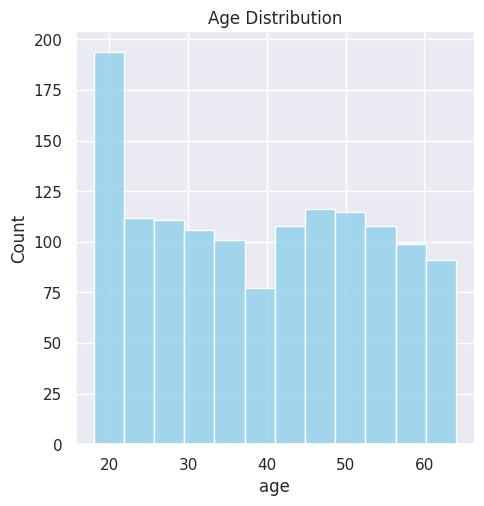

In [64]:
#Age distribution in Dataset

sns.set()
plt.figure(figsize=(3,3))
sns.displot(medic['age'], color='skyblue')
plt.title('Age Distribution')
plt.show()

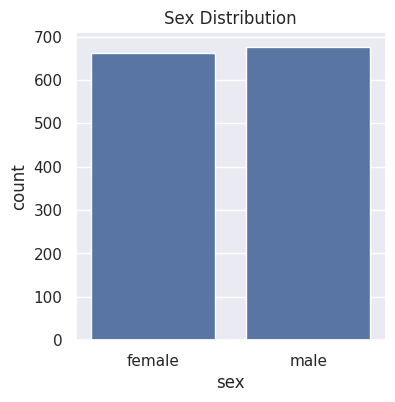

In [58]:
# Sex Distribution in Dataset
sns.set()
plt.figure(figsize=(4,4))
sns.countplot(x='sex', data=medic)
plt.title('Sex Distribution')
plt.show()

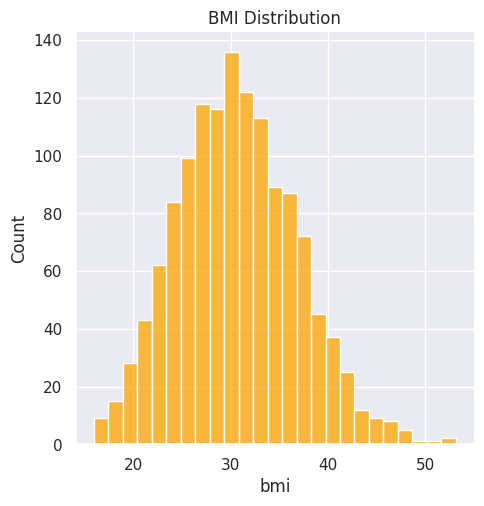

In [67]:
#BMI
sns.set()
sns.displot(medic['bmi'],color='orange')
plt.title('BMI Distribution')
plt.show()

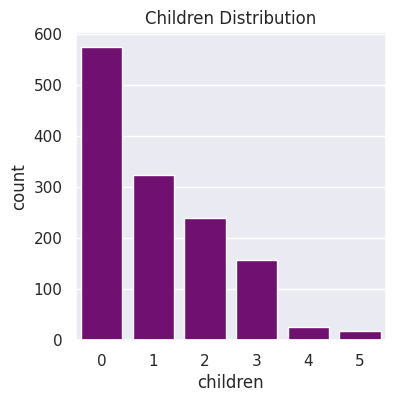

In [69]:
#Childern to patients
sns.set()
plt.figure(figsize=(4,4))
sns.countplot(x='children', data=medic, color='purple')
plt.title('Children Distribution')
plt.show()

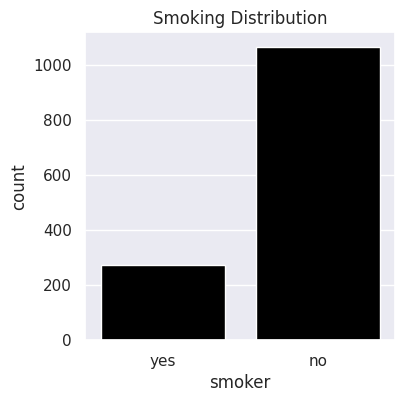

In [71]:
#Smoking
sns.set()
plt.figure(figsize=(4,4))
sns.countplot(x="smoker", data=medic, color='black')
plt.title('Smoking Distribution')
plt.show()

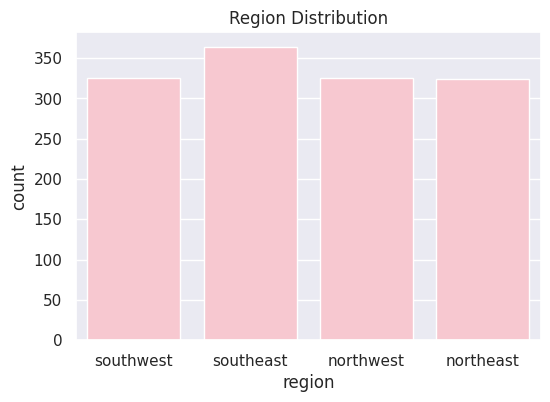

In [75]:
#Region
sns.set()
plt.figure(figsize=(6,4))
sns.countplot(x="region", data=medic, color='pink')
plt.title('Region Distribution')
plt.show()

<Figure size 400x400 with 0 Axes>

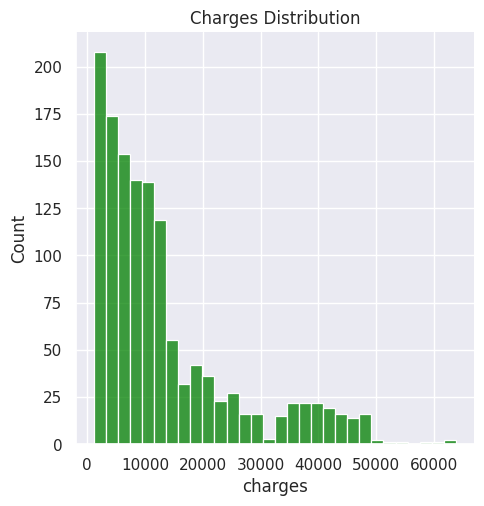

In [76]:
#Charges
sns.set()
plt.figure(figsize=(4,4))
sns.displot(medic['charges'], color='green')
plt.title('Charges Distribution')
plt.show()

# Categorical Encoding

In [77]:
medic =  pd.get_dummies(medic, columns=['sex','smoker','region'], drop_first=True)
medic.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# Data-Preprocessing

In [78]:
X = medic.drop('charges', axis=1)
y = medic['charges']

In [79]:
X.head(5)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


NOTE:

***Why not "NorthEast" shown her;***

- The model still "knows" about that category — it's just implicitly represented when all others are 0.

- if want that also - pd.get_dummies(data, drop_first=False)

But But - But for linear models, it's best to keep drop_first=True to **maintain mathematical stability**.!!!

# Train-Test

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.23, random_state=42)

In [81]:
modelL = LinearRegression()
modelR = Ridge()
modelS = SVR()
modelD = DecisionTreeRegressor()
modelRF = RandomForestRegressor()
modelX = XGBRegressor()

In [82]:
modelL.fit(X_train, y_train)
modelR.fit(X_train, y_train)
modelS.fit(X_train, y_train)
modelD.fit(X_train, y_train)
modelRF.fit(X_train, y_train)
modelX.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

# **Results on Models**

Linear Regression

In [83]:
X_train_predL = modelL.predict(X_train)
X_test_predL = modelL.predict(X_test)

mse_trainL = mean_squared_error(y_train, X_train_predL)
mse_testL = mean_squared_error(y_test, X_test_predL)

rmse_trainL = sqrt(mse_trainL)
rmse_testL = sqrt(mse_testL)

mae_trainL = mean_absolute_error(y_train, X_train_predL)
mae_testL = mean_absolute_error(y_test, X_test_predL)

r2_trainL = r2_score(y_train, X_train_predL)
r2_testL = r2_score(y_test, X_test_predL)

print("RMSE (Train):", rmse_trainL)
print("RMSE (Test):", rmse_testL)
print()
print("MAE (Train):", mae_trainL)
print("MAE (Test):", mae_testL)
print()
print("R2 Score (Train):", r2_trainL)
print("R2 Score (Test):", r2_testL)

RMSE (Train): 6059.46835577873
RMSE (Test): 5994.704341262546

MAE (Train): 4184.162008226924
MAE (Test): 4284.995512042195

R2 Score (Train): 0.7435905245821313
R2 Score (Test): 0.7721641266971442


Ridge


In [84]:
X_train_predR = modelR.predict(X_train)
X_test_predR = modelR.predict(X_test)

mse_trainR = mean_squared_error(y_train, X_train_predR)
mse_testR = mean_squared_error(y_test, X_test_predR)

rmse_trainR = sqrt(mse_trainR)
rmse_testR = sqrt(mse_testR)

mae_trainR = mean_absolute_error(y_train, X_train_predR)
mae_testR = mean_absolute_error(y_test, X_test_predR)

r2_trainR = r2_score(y_train, X_train_predR)
r2_testR = r2_score(y_test, X_test_predR)

print("RMSE (Train):", rmse_trainR)
print("RMSE (Test:)", rmse_testR)
print()
print("MAE (Train):", mae_trainR)
print("MAE (Test):", mae_testR)
print()
print("R2 Score (Train):", r2_trainR)
print("R2 Score (Test):", r2_testR)

RMSE (Train): 6059.735929624117
RMSE (Test:) 5999.228838252773

MAE (Train): 4193.764826285178
MAE (Test): 4298.058641249666

R2 Score (Train): 0.7435678790363149
R2 Score (Test): 0.7718200791251318


SVR

In [85]:
X_train_predS = modelS.predict(X_train)
X_test_predS = modelS.predict(X_test)

mse_trainS = mean_squared_error(y_train, X_train_predS)
mse_testS = mean_squared_error(y_test, X_test_predS)

rmse_trainS = sqrt(mse_trainS)
rmse_testS = sqrt(mse_testS)

mae_trainS = mean_absolute_error(y_train, X_train_predS)
mae_testS = mean_absolute_error(y_test, X_test_predS)

r2_trainS = r2_score(y_train, X_train_predS)
r2_testS = r2_score(y_test, X_test_predS)

print("RMSE (Train):", rmse_trainS)
print("RMSE (Test):", rmse_testS)
print()
print("MAE (Train):", mae_trainS)
print("MAE (Test):", mae_testS)
print()
print("R2 Score (Train):", r2_trainS)
print("R2 Score (Test):", r2_testS)

RMSE (Train): 12529.045900372526
RMSE (Test): 13102.02225111134

MAE (Train): 8210.76324607261
MAE (Test): 8667.196322449217

R2 Score (Train): -0.0962283443794798
R2 Score (Test): -0.08833659894098944


Decision Tree Regressor

In [86]:
X_train_predD = modelD.predict(X_train)
X_test_predD = modelD.predict(X_test)

mse_trainD = mean_squared_error(y_train, X_train_predD)
mse_testD = mean_squared_error(y_test, X_test_predD)

rmse_trainD = sqrt(mse_trainD)
rmse_testD = sqrt(mse_testD)

mae_trainD = mean_absolute_error(y_train, X_train_predD)
mae_testD = mean_absolute_error(y_test, X_test_predD)

r2_trainD = r2_score(y_train, X_train_predD)
r2_testD = r2_score(y_test, X_test_predD)

print("RMSE (Train):", rmse_trainD)
print("RMSE (Test):", rmse_testD)
print()
print("MAE (Train):", mae_trainD)
print("MAE (Test):", mae_testD)
print()
print("R2 Score (Train):", r2_trainD)
print("R2 Score (Test):", r2_testD)

RMSE (Train): 503.7108154690432
RMSE (Test): 6669.899521321702

MAE (Train): 30.720962524271844
MAE (Test): 2957.009569753247

R2 Score (Train): 0.9982281474479565
R2 Score (Test): 0.7179506184545803


Random Forest Regressor

In [87]:
X_train_predRF = modelRF.predict(X_train)
X_test_predRF = modelRF.predict(X_test)

mse_trainRF = mean_squared_error(y_train, X_train_predRF)
mse_testRF = mean_squared_error(y_test, X_test_predRF)

rmse_trainRF = sqrt(mse_trainRF)
rmse_testRF = sqrt(mse_testRF)

mae_trainRF = mean_absolute_error(y_train, X_train_predRF)
mae_testRF = mean_absolute_error(y_test, X_test_predRF)

r2_trainRF = r2_score(y_train, X_train_predRF)
r2_testRF = r2_score(y_test, X_test_predRF)

print("RMSE (Train):", rmse_trainRF)
print("RMSE (Test):", rmse_testRF)
print()
print("MAE (Train):", mae_trainRF)
print("MAE (Test):", mae_testRF)
print()
print("R2 Score (Train):", r2_trainRF)
print("R2 Score (Test):", r2_testRF)

RMSE (Train): 1952.4941213059042
RMSE (Test): 4772.9593394328795

MAE (Train): 1078.4653910971035
MAE (Test): 2654.2832351329553

R2 Score (Train): 0.9733777659978478
R2 Score (Test): 0.855568461306262


XBG Regressor

In [123]:
X_train_predX = modelX.predict(X_train)
X_test_predX = modelX.predict(X_test)

mse_trainX = mean_squared_error(y_train, X_train_predX)
mse_testX = mean_squared_error(y_test, X_test_predX)

rmse_trainX = sqrt(mse_trainX)
rmse_testX = sqrt(mse_testX)

mae_trainX = mean_absolute_error(y_train, X_train_predX)
mae_testX = mean_absolute_error(y_test, X_test_predX)

r2_trainX = r2_score(y_train, X_train_predX)
r2_testX = r2_score(y_test, X_test_predX)

print("RMSE (Train):", rmse_trainX)
print("RMSE (Test):", rmse_testX)
print()
print("MAE (Train):", mae_trainX)
print("MAE (Test):", mae_testX)
print()
print("R2 Score (Train):", r2_trainX)
print("R2 Score (Test):", r2_testX)

RMSE (Train): 911.251846447745
RMSE (Test): 4953.866707985049

MAE (Train): 466.9536538320692
MAE (Test): 2772.4723457752207

R2 Score (Train): 0.994201150076245
R2 Score (Test): 0.8444123208268619


# **Data Comparision**

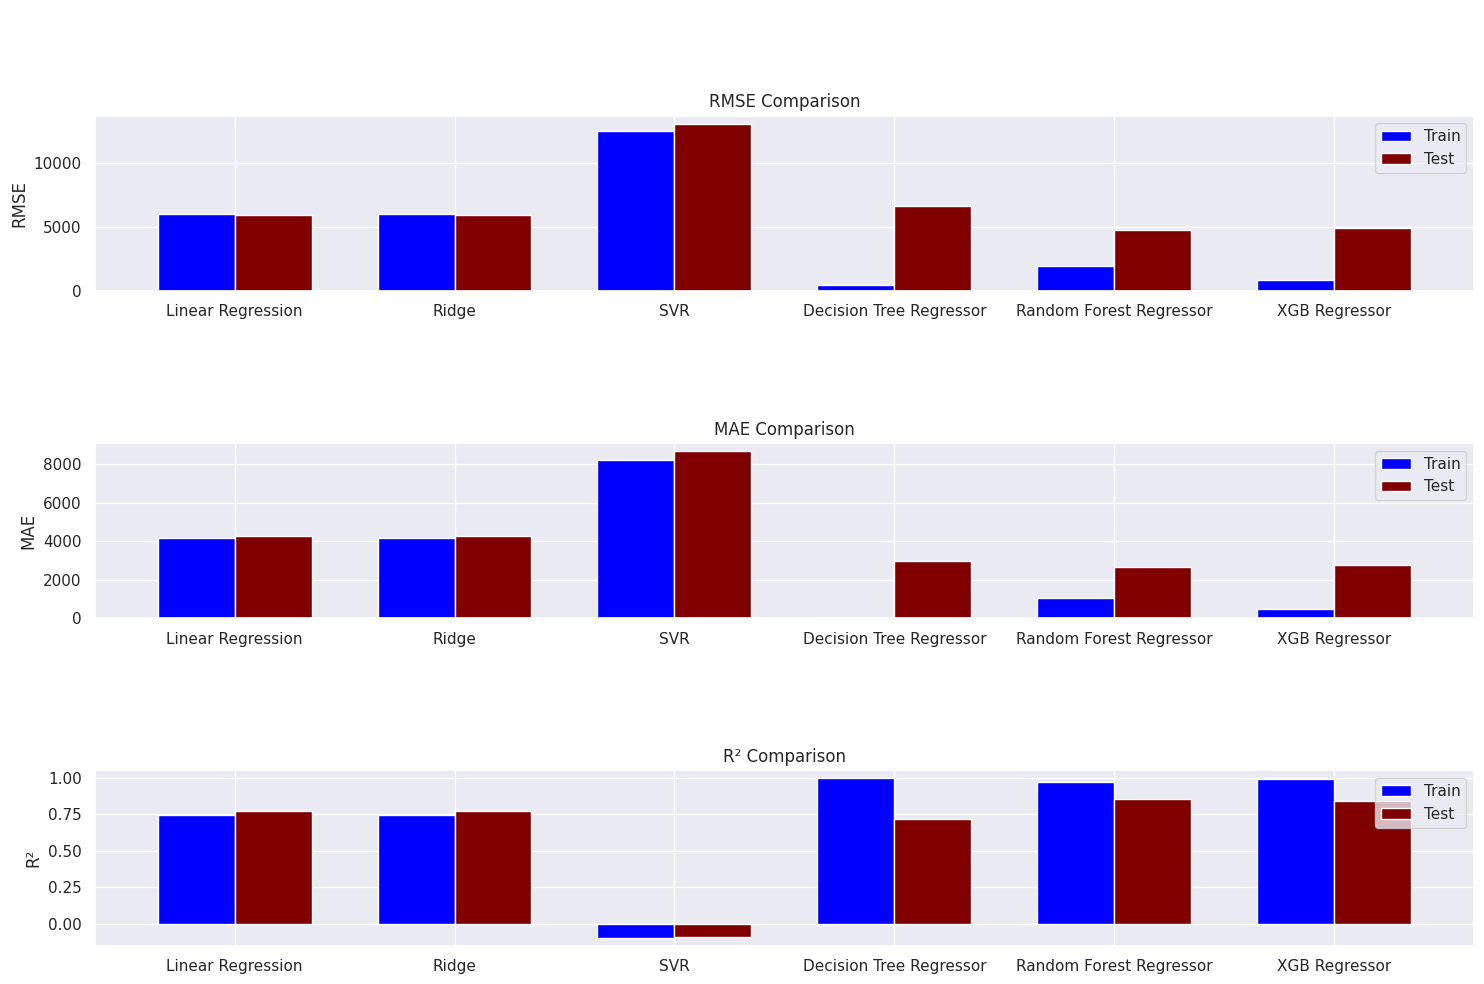

In [124]:
plt.figure(figsize=(15, 10))

names = ['Linear Regression', 'Ridge', 'SVR', 'Decision Tree Regressor', 'Random Forest Regressor', 'XGB Regressor']

rmse_train = [rmse_trainL, rmse_trainR, rmse_trainS, rmse_trainD, rmse_trainRF, rmse_trainX]
rmse_test = [rmse_testL, rmse_testR, rmse_testS, rmse_testD, rmse_testRF, rmse_testX]

mae_train = [mae_trainL, mae_trainR, mae_trainS, mae_trainD, mae_trainRF, mae_trainX]
mae_test = [mae_testL, mae_testR, mae_testS, mae_testD, mae_testRF, mae_testX]

r2_train = [r2_trainL, r2_trainR, r2_trainS, r2_trainD, r2_trainRF, r2_trainX]
r2_test = [r2_testL, r2_testR, r2_testS, r2_testD, r2_testRF, r2_testX]

list_train = [rmse_train, mae_train, r2_train]
list_test = [rmse_test, mae_test, r2_test]
list_metrics = ['RMSE', 'MAE', 'R²']

for i in range(len(list_metrics)):
    x = np.arange(len(names))
    width = 0.35

    plt.subplot(3,1,i+1)

    train_data = list_train[i]
    test_data = list_test[i]

    plt.bar(x-width/2, train_data, width, label="Train", color='blue')
    plt.bar(x+width/2, test_data, width, label="Test", color="maroon")

    plt.ylabel(list_metrics[i])
    plt.xticks(x, names)
    plt.legend()
    plt.title(f"\n\n\n\n{list_metrics[i]} Comparison")

plt.tight_layout()
plt.show()

# **Predictive System : From Dataset**

In [131]:
# X_test.count()

In [138]:
# input_data = (31, 25.74, 0, 1, 0, 1, 0, 0)
n=int(input("Enter no. from 0 to 308: "))
input_data_test = X_test.iloc[n]

# Create a DataFrame from the input data with the same columns and dtypes as X_train
input_df = pd.DataFrame([input_data_test], columns=X_train.columns)

prediction = modelD.predict(input_df)
# print(prediction)

print('The insurance cost is USD ', prediction[0])
print(f"True value at the index of y_test[{n}]: ", y_test.iloc[n])

Enter no. from 0 to 308: 1
The insurance cost is USD  5469.0066
True value at the index of y_test[1]:  5272.1758


# ***User Defined System***

In [150]:
def get_user_input(selected_features):
    input_data = {}
    for feature in selected_features:
        val = input(f"Enter {feature}: ")

        if feature in ['age', 'children']:
            val = int(val)
        elif feature == 'bmi':
            val = float(val)
        else:
            val = val.lower()
        input_data[feature] = val
    return pd.DataFrame([input_data])


def preprocess_input(input_df, X_train):
    """One-hot encode and align with training columns."""
    input_encoded = pd.get_dummies(
        input_df, columns=['sex', 'smoker', 'region'], drop_first=True
   )

    # Add missing dummy columns
    for col in X_train.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0  # safer to use 0 than False

    return input_encoded[X_train.columns]


def predict_cost(model, X_train, selected_features):
    """Runs the full prediction pipeline for a single model."""
    input_df = get_user_input(selected_features)
    input_encoded = preprocess_input(input_df, X_train)

    prediction = model.predict(input_encoded)
    print(f"\n💰Predicted Insurance Cost: USD {prediction[0]:.2f}\n")


#The Orgin

names = ['linear regression', 'ridge', 'svr', 'decision tree', 'random forest', 'xgb']
models = [modelL, modelR, modelS, modelD, modelRF, modelX]

selected_features = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']

def run_predictions(X_train):
    a = int(input("How many models do you want to test? "))
    for i in range(a):
        print(f"\nAvailable models: {', '.join(names)}")
        c = input("Enter model name: ").lower()

        if c in names:
            idx = names.index(c)
            print(f"\n🔹 Selected Model: {names[idx].upper()} 🔹")
            predict_cost(models[idx], X_train, selected_features)
        else:
            print("Invalid input. Please try again.")

run_predictions(X_train)


How many models do you want to test? 2

Available models: linear regression, ridge, svr, decision tree, random forest, xgb
Enter model name: random forest

🔹 Selected Model: RANDOM FOREST 🔹
Enter age: 34
Enter sex: male
Enter bmi: 26
Enter children: 2
Enter smoker: no
Enter region: northeast

💰Predicted Insurance Cost: USD 7390.70


Available models: linear regression, ridge, svr, decision tree, random forest, xgb
Enter model name: decision tree

🔹 Selected Model: DECISION TREE 🔹
Enter age: 34
Enter sex: male
Enter bmi: 26
Enter children: 2
Enter smoker: no
Enter region: northeast

💰Predicted Insurance Cost: USD 11737.85

